In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline





In [2]:
data=pd.read_csv(r"E:\FCDS\Semester 6\Data Computation\Projects\star_classification.csv")

In [3]:
data.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237660e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606.0,301.0,2.0,79.0,6.543780e+18,GALAXY,0.634794,5812.0,56354.0,171.0
1,1.237660e+18,144.826101,31.274185,24.77759,22.83188,NaN,21.16812,21.61427,4518.0,301.0,5.0,119.0,1.176010e+19,GALAXY,0.779136,10445.0,58158.0,427.0
2,1.237660e+18,142.188790,35.582444,25.26307,22.66389,NaN,19.34857,18.94827,3606.0,301.0,2.0,120.0,5.152200e+18,GALAXY,0.644195,4576.0,55592.0,299.0
3,1.237660e+18,338.741038,-0.402828,22.13682,23.77656,NaN,20.50454,19.25010,4192.0,301.0,3.0,214.0,1.030110e+19,GALAXY,0.932346,9149.0,58039.0,775.0
4,1.237680e+18,NaN,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102.0,301.0,3.0,137.0,6.891860e+18,GALAXY,0.116123,6121.0,56187.0,842.0


In [4]:
data.shape

(100085, 18)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100085 entries, 0 to 100084
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100085 non-null  float64
 1   alpha        100083 non-null  float64
 2   delta        100079 non-null  float64
 3   u            100082 non-null  float64
 4   g            100082 non-null  float64
 5   r            100081 non-null  float64
 6   i            100083 non-null  float64
 7   z            100081 non-null  float64
 8   run_ID       100082 non-null  float64
 9   rerun_ID     100084 non-null  float64
 10  cam_col      100084 non-null  float64
 11  field_ID     100084 non-null  float64
 12  spec_obj_ID  100083 non-null  float64
 13  class        100085 non-null  object 
 14  redshift     100083 non-null  float64
 15  plate        100081 non-null  float64
 16  MJD          100081 non-null  float64
 17  fiber_ID     100082 non-null  float64
dtypes: float64(17), object(1

------------------------------------------------------------------------------------
Data Cleaning
---------------------------------------------------------------------------------------


-------------------------------------------------------
Remove duplicated
---------------------------------------------------------------

In [6]:
data.duplicated().sum()

79

In [7]:
data.drop_duplicates(inplace=True)

In [8]:
data.duplicated().sum()

0

In [9]:
data.nunique() == 1 #rerun_ID ==>    True


obj_ID         False
alpha          False
delta          False
u              False
g              False
r              False
i              False
z              False
run_ID         False
rerun_ID        True
cam_col        False
field_ID       False
spec_obj_ID    False
class          False
redshift       False
plate          False
MJD            False
fiber_ID       False
dtype: bool

In [10]:
data.drop("rerun_ID", axis=1,inplace=True)

In [11]:
data.drop("obj_ID",axis=1,inplace=True)

In [12]:
data.head(10)

,alpha,delta,u,g,r,i,z,run_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606.0,2.0,79.0,6.543780e+18,GALAXY,0.634794,5812.0,56354.0,171.0
1,144.826101,31.274185,24.77759,22.83188,NaN,21.16812,21.61427,4518.0,5.0,119.0,1.176010e+19,GALAXY,0.779136,10445.0,58158.0,427.0
2,142.188790,35.582444,25.26307,22.66389,NaN,19.34857,18.94827,3606.0,2.0,120.0,5.152200e+18,GALAXY,0.644195,4576.0,55592.0,299.0
3,338.741038,-0.402828,22.13682,23.77656,NaN,20.50454,19.25010,4192.0,3.0,214.0,1.030110e+19,GALAXY,0.932346,9149.0,58039.0,775.0
4,NaN,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102.0,3.0,137.0,6.891860e+18,GALAXY,0.116123,6121.0,56187.0,842.0
5,340.995120,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102.0,3.0,110.0,5.658980e+18,QSO,1.424659,5026.0,55855.0,741.0
6,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773.0,2.0,462.0,1.250000e+19,QSO,0.586455,11069.0,58456.0,113.0
7,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,NaN,2.0,346.0,6.961440e+18,GALAXY,0.477009,6183.0,56210.0,15.0
8,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716.0,5.0,108.0,7.459280e+18,GALAXY,0.660012,6625.0,56386.0,719.0
9,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934.0,4.0,122.0,2.751760e+18,STAR,-0.000008,2444.0,54082.0,232.0


In [13]:
len(data["run_ID"].unique())

431

In [14]:
len(data["field_ID"].unique())

857

In [15]:
len(data["spec_obj_ID"].unique())

57189

----------------------------------------------------------------------------------------------
Fill NULL
-------------------

In [16]:
data.isnull().sum()

alpha          2
delta          6
u              3
g              3
r              4
i              2
z              4
run_ID         3
cam_col        1
field_ID       1
spec_obj_ID    2
class          0
redshift       2
plate          4
MJD            4
fiber_ID       3
dtype: int64

In [17]:
means = data.mean(numeric_only=True)
data = data.fillna(means)

------------------------------------
Remove Outliers
------------------------------------------

C:\Users\Hamza\AppData\Local\Temp\ipykernel_15464\779292893.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[col] for col in numeric_cols], labels=numeric_cols)


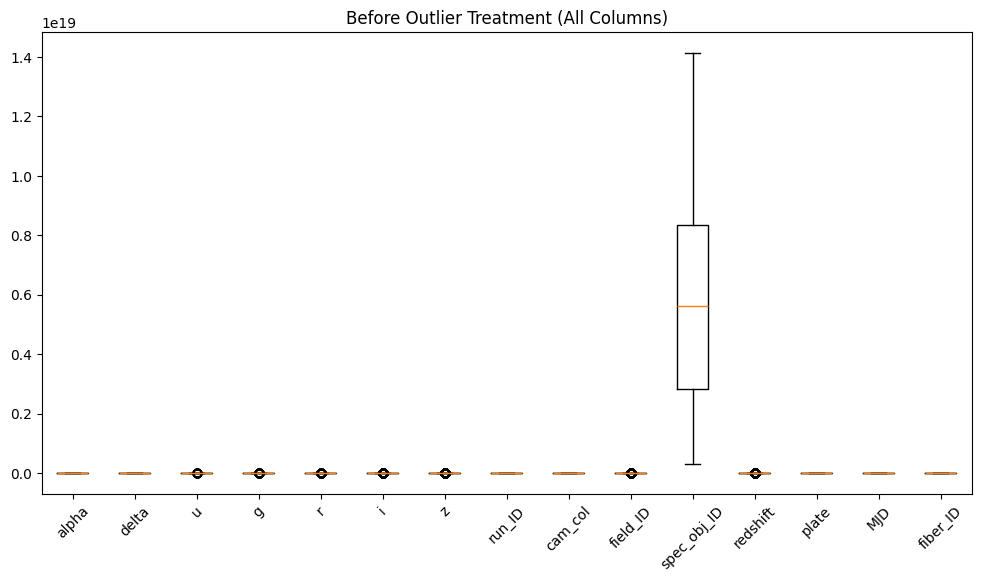

In [18]:
numeric_cols = data.select_dtypes(include='number').columns
plt.figure(figsize=(12,6))

plt.boxplot([data[col] for col in numeric_cols], labels=numeric_cols)

plt.title("Before Outlier Treatment (All Columns)")
plt.xticks(rotation=45)

plt.show()

In [19]:
numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)    #outlierبيشيل الصف اللي جواه 
    print(col, len(data))

alpha 100006
delta 100006
u 100006
g 100006
r 100006
i 100006
z 100006
run_ID 100006
cam_col 100006
field_ID 100006
spec_obj_ID 100006
redshift 100006
plate 100006
MJD 100006
fiber_ID 100006


C:\Users\Hamza\AppData\Local\Temp\ipykernel_15464\3504119535.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[col] for col in numeric_cols], labels=numeric_cols)


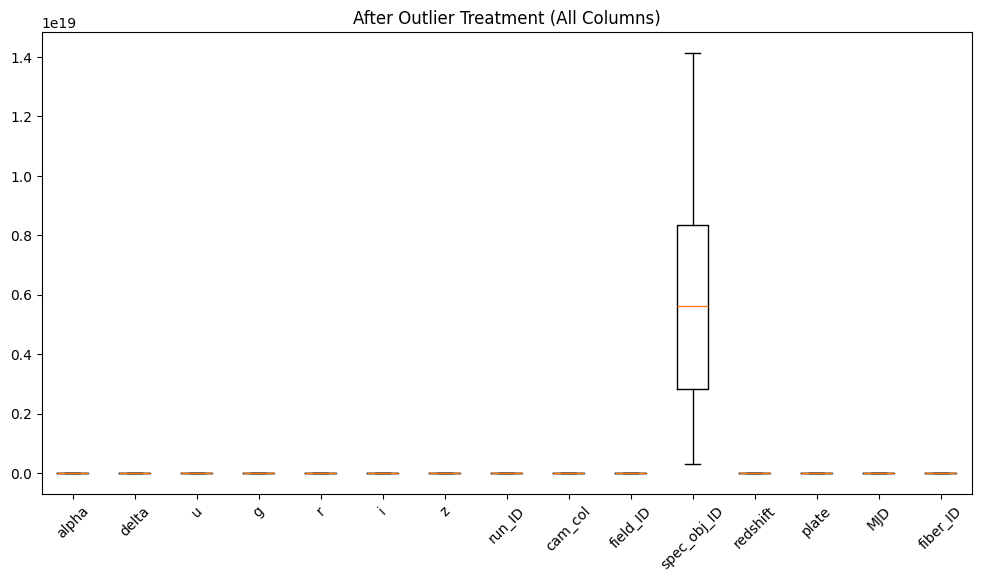

In [20]:
numeric_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))

plt.boxplot([data[col] for col in numeric_cols], labels=numeric_cols)

plt.title("After Outlier Treatment (All Columns)")
plt.xticks(rotation=45)

plt.show()

--------------------------------------------------------

In [21]:

le = LabelEncoder()
data['class'] = le.fit_transform(data['class'])

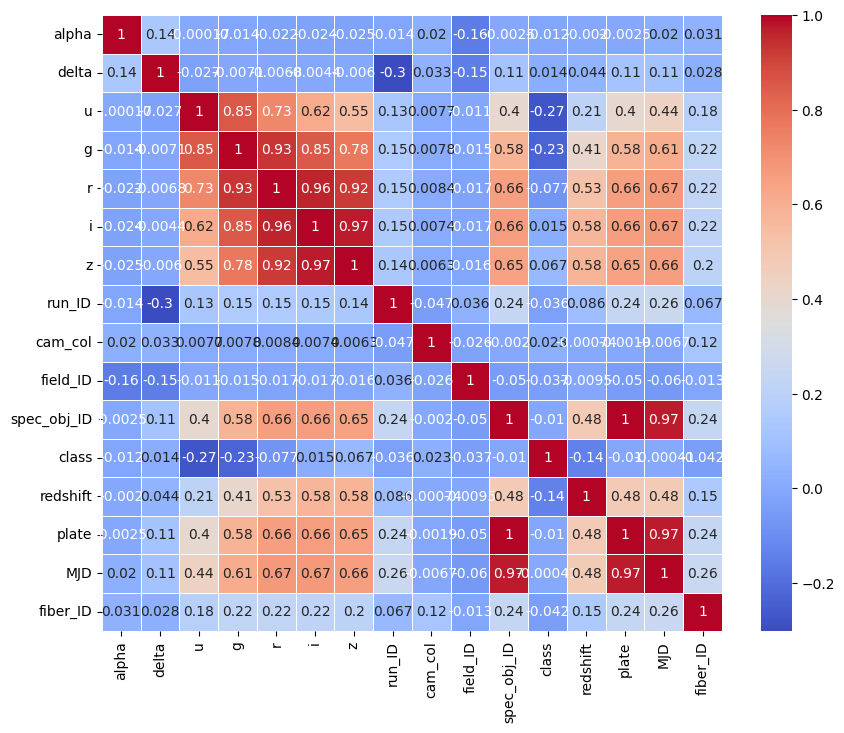

In [22]:
plt.figure(figsize=(10, 8))
cor = data.corr()
sns.heatmap(cor, annot=True, cmap="coolwarm", linewidths=0.5)
plt.show()

In [23]:
data.drop("MJD",axis=1,inplace=True) #0.0004 corr with target "class"

-------------------------------------
Split Data into Train Test 
-------------------------------------


In [24]:
train, test= train_test_split(
    data,
    test_size=0.2,
    random_state=1)
train.shape, test.shape

((80004, 15), (20002, 15))

In [25]:
x_train = train.drop("class", axis=1)
y_train=train.loc[:,"class"]
x_test= test.drop("class", axis=1)
y_test=test.loc[:,"class"]


-------------------------------------
Normalization & PCA & LDA & SVM
----------------------


In [27]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ("pca",PCA()),
    ("lda",LDA()),
    ('svc', SVC())
])

In [30]:
param_grid = {
    'pca__n_components': range(2,19),
    'lda__n_components': [1,2],
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf'],
    'svc__gamma': ['scale', 'auto']
}

In [ ]:
grid = GridSearchCV(
    pipe,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(x_train, y_train)

In [ ]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='viridis', s=3)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

xy = np.c_[XX.ravel(), YY.ravel()]
Z = best_model.predict(xy)
Z = Z.reshape(XX.shape)

ax.contourf(XX, YY, Z, alpha=0.3)

plt.title("SVM Decision Boundary")
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.show()